In [2]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 4 - TIMESERIES
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt


In [3]:
#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
f1=freq[0]
f2=freq[1]



In [4]:
# ====== LOAD SPECTRA RESULTS ======

spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')

f_axis= spec['f_axis']
omega_axis=spec['omega_axis']
U10_LC1=float(spec['U10_LC1'])
U10_LC2=float(spec['U10_LC2'])
Tp_LC1=float(spec['Tp_LC1'])
Tp_LC2=float(spec['Tp_LC2'])
Hs_LC1=float(spec['Hs_LC1'])
Hs_LC2=float(spec['Hs_LC2'])
U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']
S_kaimal_LC1=spec['S_kaimal_LC1']
S_kaimal_LC2=spec['S_kaimal_LC2']
S_co_LC1=spec['S_co_LC1']
S_co_LC2=spec['S_co_LC2']
S_jonswap_LC1=spec['S_jonswap_LC1']
S_jonswap_LC2=spec['S_jonswap_LC2']
omega_p_LC1=float(spec['omega_p_LC1'])
omega_p_LC2=float(spec['omega_p_LC2'])



C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\3863092988.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U10_LC1=float(spec['U10_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\3863092988.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U10_LC2=float(spec['U10_LC2'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\3863092988.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Tp_LC1=float(spec['Tp_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipyke

In [5]:
# ======== TIME =========
dt=0.05 # time step [s]
T_total=1800 # duration [s] - will check convergence
N_t=int(T_total/dt) # number of time steps
t=np.arange(N_t)*dt # time array [s]

np.random.seed(17) # fixed seed for reproducibility

print(f"Time series duration: {T_total} s")
print(f"Time step: {dt} s")
print(f"Number of steps: {N_t}")
print(f"Nyquist frequency: {1/(2*dt):.2f} Hz (f_max={f_axis[-1]:.2f} Hz)")



Time series duration: 1800 s
Time step: 0.05 s
Number of steps: 36000
Nyquist frequency: 10.00 Hz (f_max=2.42 Hz)


In [6]:
# ===== WIND TIME SERIES =====
df=f_axis[1]-f_axis[0] # frequency resolution [Hz]
n_air=len(air_nodes)

# amplitude at each frequency for each air node
# shape: (n_air, N_freq)
A_wind_LC1=np.sqrt(2*S_kaimal_LC1*df) # [m/s]
A_wind_LC2=np.sqrt(2*S_kaimal_LC2*df) # [m/s]

# random phase angles - one per frequency, same for all nodes
# (spatial correlation handled by co-spectrum later)
phi_wind=np.random.uniform(0, 2*np.pi, len(f_axis))

# generate time series at each air node
# u(t)=sum_n A_n*cos(2*pi*f_n*t + phi_n)
u_wind_LC1=np.zeros((n_air, N_t))
u_wind_LC2=np.zeros((n_air, N_t))

for i in range(n_air):
    for k, fk in enumerate(f_axis):
        u_wind_LC1[i, :] += A_wind_LC1[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        u_wind_LC2[i, :] += A_wind_LC2[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        
print(f"\n Wind Time Series")
print(f"LC1 std dev at hub: {np.std(u_wind_LC1[-1,:]):.3f} m/s")
print(f"LC2 std dev at hub: {np.std(u_wind_LC2[-1,:]):.3f} m/s")
print(f"Expected LC1 (I_u*U_hub): {0.06*U_mean_LC1[air_nodes[-1]]:.3f} m/s")
print(f"Expected LC2 (I_u*U_hub): {0.06*U_mean_LC2[air_nodes[-1]]:.3f} m/s")




 Wind Time Series
LC1 std dev at hub: 0.569 m/s
LC2 std dev at hub: 1.262 m/s
Expected LC1 (I_u*U_hub): 0.699 m/s
Expected LC2 (I_u*U_hub): 1.435 m/s


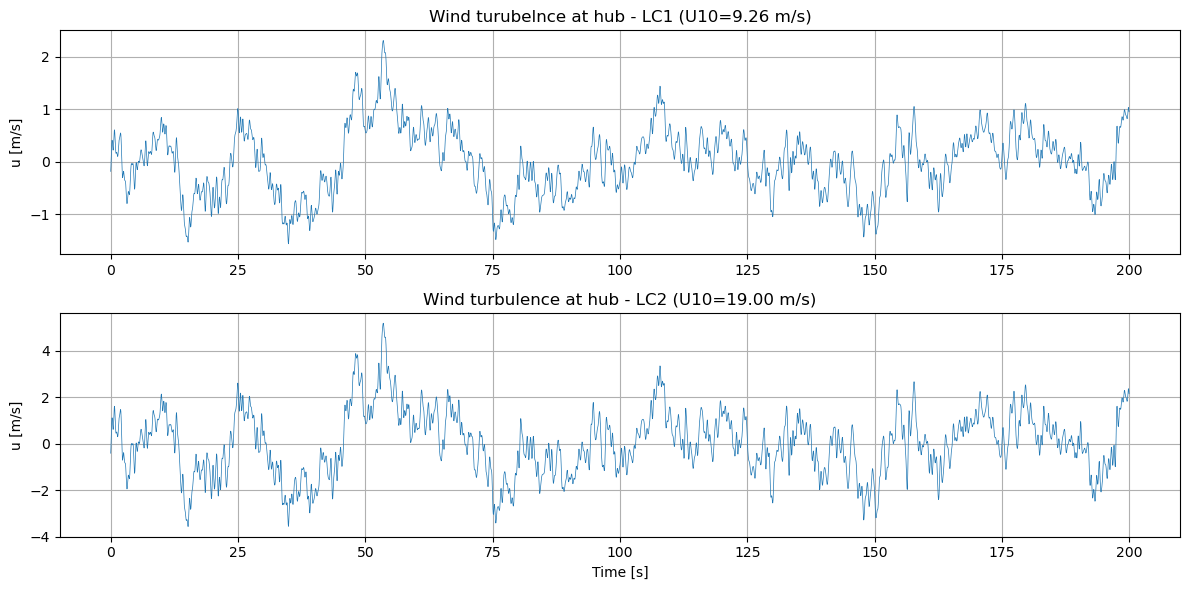

In [7]:
# plot first 200 seconds at hub for both load cases
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], u_wind_LC1[-1, :4000], linewidth=0.5)
axes[0].set_ylabel('u [m/s]')
axes[0].set_title(f'Wind turubelnce at hub - LC1 (U10={U10_LC1:.2f} m/s)')
axes[0].grid(True)

axes[1].plot(t[:4000], u_wind_LC2[-1, :4000],linewidth=0.5)
axes[1].set_ylabel('u [m/s]')
axes[1].set_title(f'Wind turbulence at hub - LC2 (U10={U10_LC2:.2f} m/s)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [8]:
# ==== WAVE TIME SERIES ======
g=9.81
h=Hw # water depth [m]

# Wave amplitudes from JONSWAP spectrum
domega=omega_axis[1]-omega_axis[0]
A_wave_LC1=np.sqrt(2*S_jonswap_LC1*domega)
A_wave_LC2=np.sqrt(2*S_jonswap_LC2*domega)

# random phase angles for waves
phi_wave_LC1=np.random.uniform(0,2*np.pi, len(omega_axis))
phi_wave_LC2=np.random.uniform(0,2*np.pi, len(omega_axis))

# solve dispersion relation for wave numbers
from dynamics_tools import wave_numbers
k_arr_LC1= wave_numbers(omega_axis, h)
k_arr_LC2= wave_numbers(omega_axis, h)

print(f"k_arr_LC2 range: {k_arr_LC1[0]:.6f} to {k_arr_LC1[-1]:.4f} rad/m")
print(f"k*h range LC1: {k_arr_LC1[0]*h:.6f} to {k_arr_LC1[-1]*h:.4f}")
print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")



k_arr_LC2 range: 0.003352 to 23.6520 rad/m
k*h range LC1: 0.120655 to 851.4712
sinh(k*h) min LC1: 0.120948


C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\3147449354.py:21: RuntimeWarning: overflow encountered in sinh
  print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")


In [9]:
# surface elevation time series
eta_LC1=np.zeros(N_t)
eta_LC2=np.zeros(N_t)

for k, omk in enumerate(omega_axis):
    eta_LC1 += A_wave_LC1[k]*np.cos(omk*t+phi_wave_LC1[k])
    eta_LC2 += A_wave_LC2[k]*np.cos(omk*t+phi_wave_LC2[k])

print(f"\n Wave Time Series")
print(f"LC1 Hs estimate (4*std): {4*np.std(eta_LC1):.3f} m (target: {Hs_LC1:.3f} m )")
print(f"LC2 Hs estimate (4*std): {4*np.std(eta_LC2):.3f} m (target: {Hs_LC2:.3f} m )")

Hs_check_LC1=4*np.sqrt(np.sum(S_jonswap_LC1*domega))
Hs_check_LC2=4*np.sqrt(np.sum(S_jonswap_LC2*domega))
print(f"Hs from spectrum LC1: {Hs_check_LC1:.3f} m")
print(f"Hs from spectrum LC2: {Hs_check_LC2:.3f} m")




 Wave Time Series
LC1 Hs estimate (4*std): 2.008 m (target: 2.008 m )
LC2 Hs estimate (4*std): 4.199 m (target: 4.118 m )
Hs from spectrum LC1: 2.008 m
Hs from spectrum LC2: 4.118 m


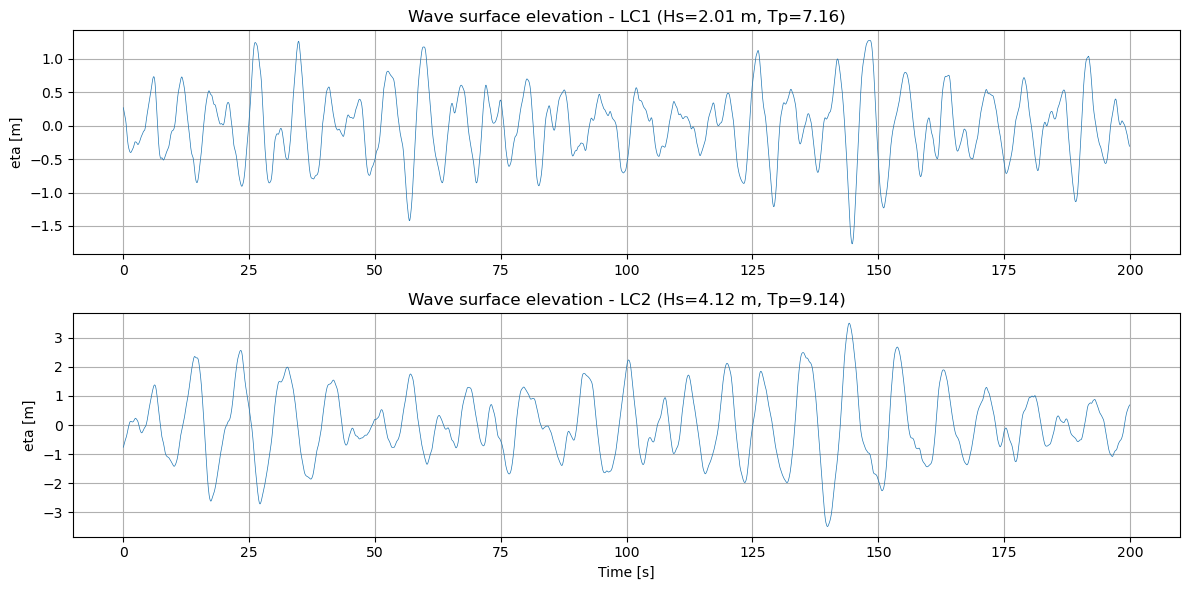

In [10]:
# plot first 200 seconds
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], eta_LC1[:4000], linewidth=0.5)
axes[0].set_ylabel('eta [m]')
axes[0].set_title(f'Wave surface elevation - LC1 (Hs={Hs_LC1:.2f} m, Tp={Tp_LC1:.2f})')
axes[0].grid(True)

axes[1].plot(t[:4000], eta_LC2[:4000], linewidth=0.5)
axes[1].set_ylabel('eta [m]')
axes[1].set_title(f'Wave surface elevation - LC2 (Hs={Hs_LC2:.2f} m, Tp={Tp_LC2:.2f})')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [11]:
# ===== WATER PARTICLE KINEMATICS =====
# submerged node heights above seabed
z_sub_nodes=z_nodes[:elem_w+1] # nodes from mudline to waterline
n_sub=len(z_sub_nodes)

# particle velocity and acceleration at each submerged node
# shape: (n_sub, N_t)
u_water_LC1=np.zeros((n_sub, N_t))
du_water_LC1=np.zeros((n_sub, N_t))
u_water_LC2=np.zeros((n_sub, N_t))
du_water_LC2=np.zeros((n_sub, N_t))

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h #convrty: 0 at mudline -> -h, h at surface -> 0
    kh_LC1=k_arr_LC1*h
    kh_LC2=k_arr_LC2*h

    # use deep water approximation where kh is large to avoid overflow
    # cosh(k(z+h))/sinh(kh) -> exp(k*z) for large kh
    
    
    depth_factor_LC1=np.where(
        kh_LC1< 50,
        np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
        np.exp(k_arr_LC1*z_from_surface)
    )
    depth_factor_LC2=np.where(
        kh_LC2 < 50,
        np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
        np.exp(k_arr_LC2*z_from_surface)
    )
    for k, omk in enumerate(omega_axis):
        #velocity
        u_water_LC1[i,:] += A_wave_LC1[k]*omk*depth_factor_LC1[k]*\
                             np.cos(omk*t+phi_wave_LC1[k])
        u_water_LC2[i,:] += A_wave_LC2[k]*omk*depth_factor_LC2[k]*\
                             np.cos(omk*t+phi_wave_LC2[k])
        # acceleration 
        du_water_LC1[i,:] += -A_wave_LC1[k]*omk**2*depth_factor_LC1[k]*\
                             np.sin(omk*t+phi_wave_LC1[k])
        du_water_LC2[i,:] += -A_wave_LC2[k]*omk**2*depth_factor_LC2[k]*\
                             np.sin(omk*t+phi_wave_LC2[k])
        
print(f"\n Water Particle Kinematics")
print(f" LC1 max velocity at surface: {np.max(abs(u_water_LC1[-1,:])):.3f} m/s")
print(f" LC2 max velocity at surface: {np.max(abs(u_water_LC2[-1,:])):.3f} m/s")
print(f"LC1 max velocity at mudline: {np.max(abs(u_water_LC1[0,:])):.3f} m/s")
print(f"LC2 max velocity at mudline: {np.max(abs(u_water_LC2[0,:])):.3f} m/s")



C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:24: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:29: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:24: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:24: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:29: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
C:\Users\gabri\AppData\Local\Temp\ipykernel_28660\1176758322.py:29: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr_LC2*(z_


 Water Particle Kinematics
 LC1 max velocity at surface: 2.233 m/s
 LC2 max velocity at surface: 3.293 m/s
LC1 max velocity at mudline: 0.153 m/s
LC2 max velocity at mudline: 0.723 m/s


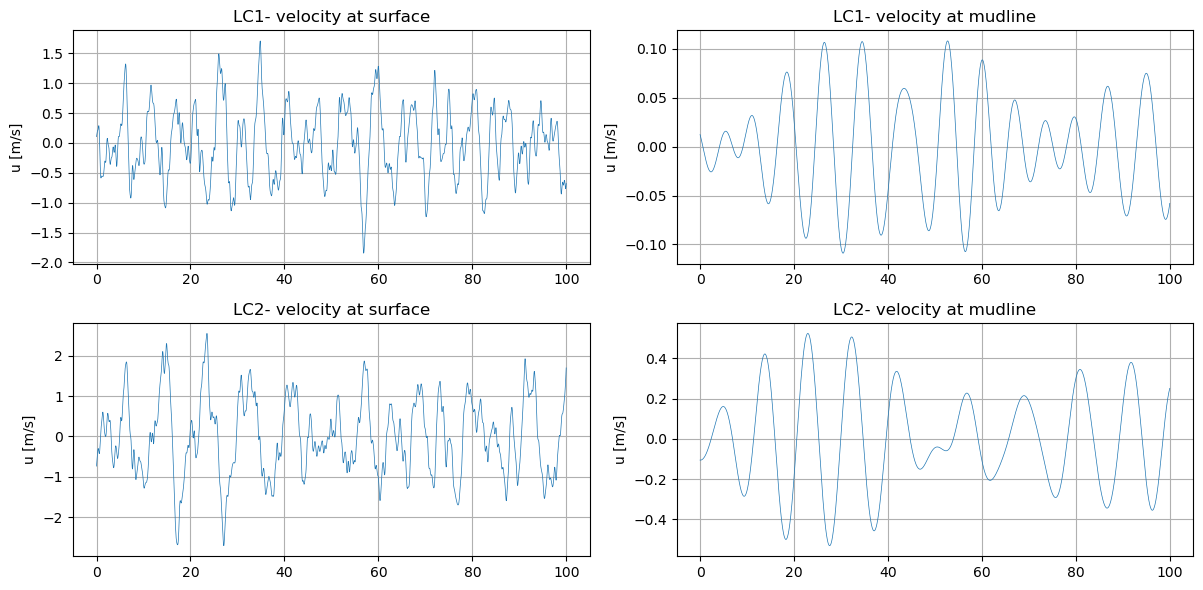

In [12]:
# plot velocity at surface and mudline
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(t[:2000], u_water_LC1[-1, :2000], linewidth=0.5)
axes[0,0].set_ylabel('u [m/s]')
axes[0,0].set_title('LC1- velocity at surface')
axes[0,0].grid(True)

axes[0,1].plot(t[:2000], u_water_LC1[0, :2000], linewidth=0.5)
axes[0,1].set_ylabel('u [m/s]')
axes[0,1].set_title('LC1- velocity at mudline')
axes[0,1].grid(True)

axes[1,0].plot(t[:2000], u_water_LC2[-1, :2000], linewidth=0.5)
axes[1,0].set_ylabel('u [m/s]')
axes[1,0].set_title('LC2- velocity at surface')
axes[1,0].grid(True)

axes[1,1].plot(t[:2000], u_water_LC2[0, :2000], linewidth=0.5)
axes[1,1].set_ylabel('u [m/s]')
axes[1,1].set_title('LC2- velocity at mudline')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()



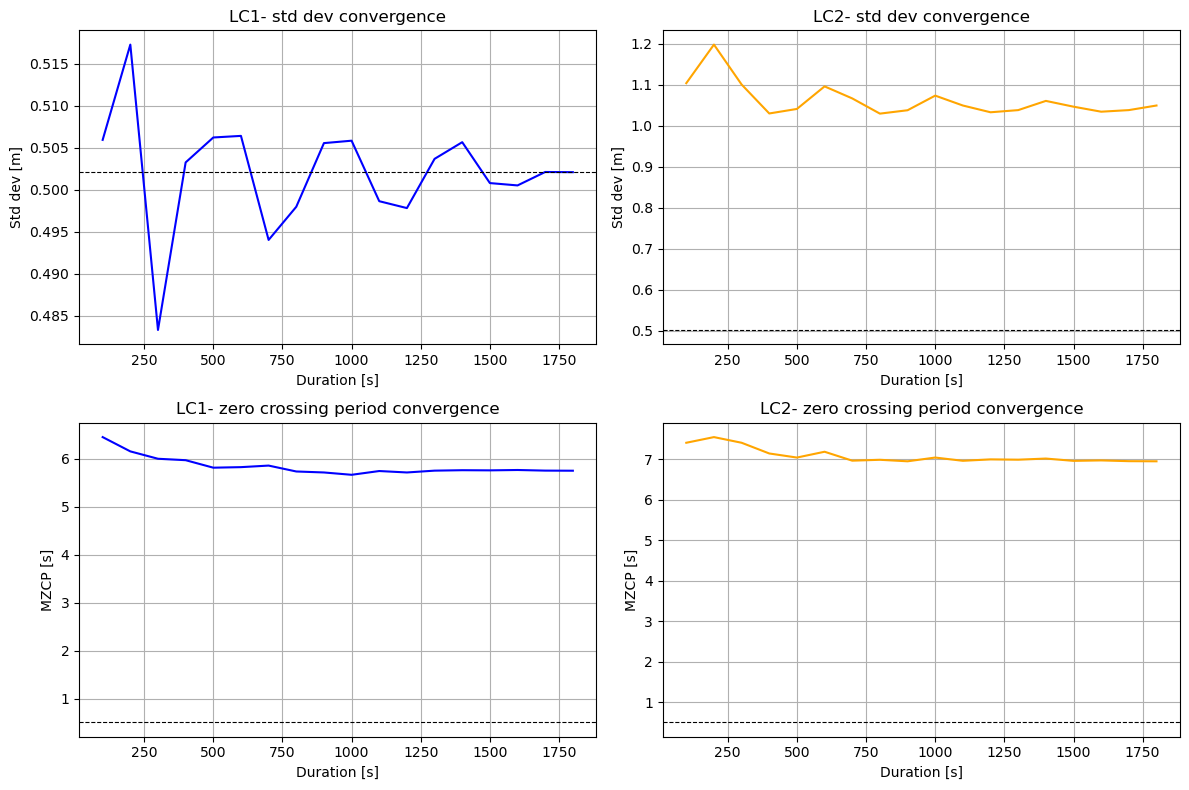


 Convergence Analysis
Final std LC1: 0.5021 m
Final std LC2: 1.0499 m
Final MZCP LC1: 5.75 s (Tp=7.16 s)
Final MZCP LC2: 5.75 s (Tp=9.14 s)


In [13]:
# ==== CONVERGENCE ANALYSIS =====
#progressively increase duration and monitor std dev and mean zero crossing period
T_lengths=np.arange(100, T_total+1, 100) # 100 to 1800 s in steps of 100

std_LC1=np.zeros(len(T_lengths))
std_LC2=np.zeros(len(T_lengths))
mzcp_LC1=np.zeros(len(T_lengths))
mzcp_LC2=np.zeros(len(T_lengths))

def mean_zero_crossing_period(signal, dt):
    # count zero crossings
    zero_crossings=np.where(np.diff(np.sign(signal)))[0]
    if len(zero_crossings) < 2:
        return np.nan
    return 2*len(signal)*dt/len(zero_crossings)

for j, T_len in enumerate(T_lengths):
    N_len=int(T_len/dt)
    # use surface elevation as the convergence signal
    std_LC1[j] =np.std(eta_LC1[:N_len])
    std_LC2[j]=np.std(eta_LC2[:N_len])
    mzcp_LC1[j]=mean_zero_crossing_period(eta_LC1[:N_len], dt)
    mzcp_LC2[j]=mean_zero_crossing_period(eta_LC2[:N_len], dt)
fig, axes=plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(T_lengths, std_LC1, 'b')
axes[0,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,0].set_xlabel('Duration [s]')
axes[0,0].set_ylabel('Std dev [m]')
axes[0,0].set_title('LC1- std dev convergence')
axes[0,0].grid(True)

axes[0,1].plot(T_lengths, std_LC2, 'orange')
axes[0,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,1].set_xlabel('Duration [s]')
axes[0,1].set_ylabel('Std dev [m]')
axes[0,1].set_title('LC2- std dev convergence')
axes[0,1].grid(True)

axes[1,0].plot(T_lengths, mzcp_LC1, 'b')
axes[1,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,0].set_xlabel('Duration [s]')
axes[1,0].set_ylabel('MZCP [s]')
axes[1,0].set_title('LC1- zero crossing period convergence')
axes[1,0].grid(True)

axes[1,1].plot(T_lengths, mzcp_LC2, 'orange')
axes[1,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,1].set_xlabel('Duration [s]')
axes[1,1].set_ylabel('MZCP [s]')
axes[1,1].set_title('LC2- zero crossing period convergence')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n Convergence Analysis")
print( f"Final std LC1: {std_LC1[-1]:.4f} m")
print( f"Final std LC2: {std_LC2[-1]:.4f} m")
print( f"Final MZCP LC1: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC1:.2f} s)")
print( f"Final MZCP LC2: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC2:.2f} s)")



In [14]:
# ==== SAVE OUTPUTS ======
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'timeseries_results.npz',
    t=t,
    dt=np.array([dt]),
    T_total=np.array([T_total]),

    #wind
    u_wind_LC1=u_wind_LC1,
    u_wind_LC2=u_wind_LC2,
    #waves
    eta_LC1=eta_LC1,
    eta_LC2=eta_LC2,
    #water kinematics
    u_water_LC1=u_water_LC1,
    du_water_LC1=du_water_LC1,
    u_water_LC2=u_water_LC2,
    du_water_LC2=du_water_LC2,
    z_sub_nodes=z_sub_nodes
)
print("\nTime series results saved to outputs/timeseries_results.npz")


Time series results saved to outputs/timeseries_results.npz
